In [2]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer

Load data

In [4]:
X,y = load_breast_cancer(return_X_y=True)
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

Split data

In [5]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

Scale Data

In [ ]:
scaler = StandardScaler()
# scale both training and testing
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

Feed to classifier

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtrain_scaled, ytrain)
y_pred = knn.predict(Xtest_scaled)
accuracy = knn.score(Xtest_scaled, ytest)
print(f"Model accuracy: {accuracy*100:.2f}%")
print(f"Predictions: {y_pred}")
print(f"Actual labels: {ytest}")

Model accuracy: 94.74%
Predictions: [1 0 0 1 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]
Actual labels: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


Actual data- Workign with data

In [8]:
data = load_breast_cancer()

In [9]:
#regression
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True).frame
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


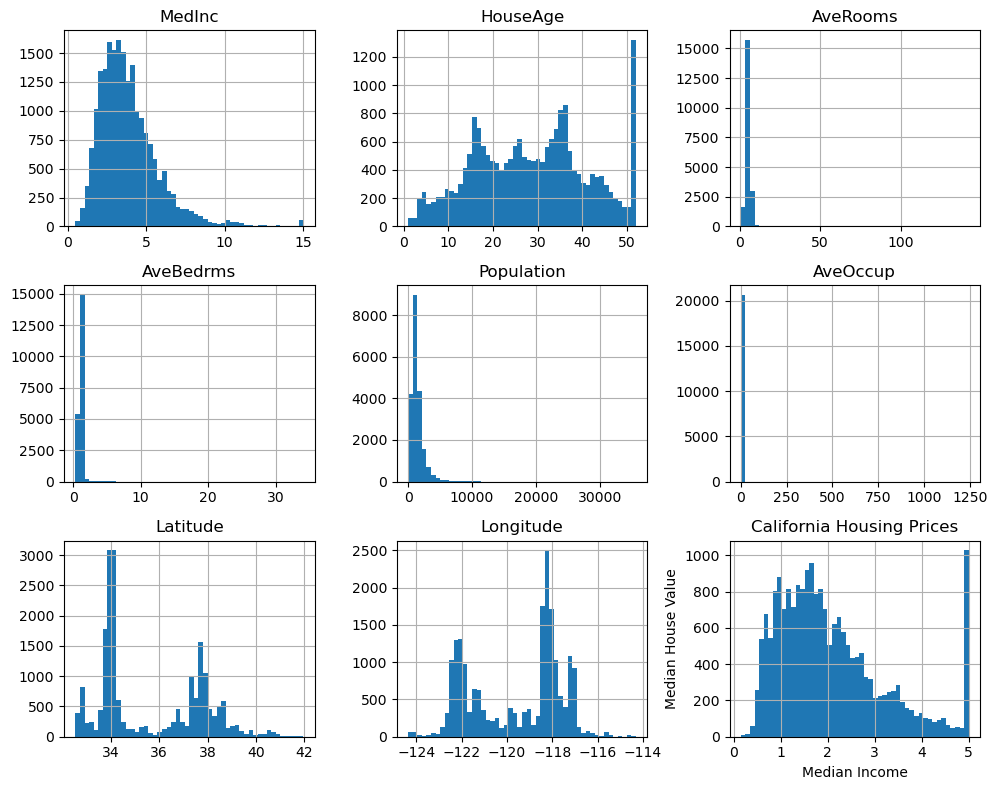

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

data.hist(bins=50, figsize=(10,8))
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('California Housing Prices')
plt.tight_layout()
plt.show()

Generate data using distribution

In [11]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

Splitting

In [14]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# STRATIFIEd shuffle split for classification problems with imbalanced classes
# when one class is significantly more frequent than others or less represented
# use StratifiedShuffleSplit to maintain class proportions in train and test sets

#stratified shuffle split pays attention to the distribution of classes in the target variable
from sklearn.model_selection import StratifiedShuffleSplit
SSsplit = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in SSsplit.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]



Preprocessing

Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
#SCALE TO mean 0 and variance 1
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [18]:
# using the minmax scaler
from sklearn.preprocessing import MinMaxScaler
#min max only has positive values between 0 and 1
minmax_scaler = MinMaxScaler()
x_train_minmax = minmax_scaler.fit_transform(X_train)
x_test_minmax = minmax_scaler.transform(X_test)

Feature Encoding

In [19]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder
data = fetch_openml(name='car',  as_frame=True).frame
data

c:\Users\User\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [20]:

# you can pass multiple columns to encode with different categories for each column
columns_to_encode = ['lug_boot', 'safety']
ode = OrdinalEncoder(categories=[['small', 'med', 'big'], ['low', 'med', 'high']]   )
data[columns_to_encode] = ode.fit_transform(data[columns_to_encode])
data


,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,0.0,0.0,P
1,vhigh,vhigh,2,2,0.0,1.0,P
2,vhigh,vhigh,2,2,0.0,2.0,P
3,vhigh,vhigh,2,2,1.0,0.0,P
4,vhigh,vhigh,2,2,1.0,1.0,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,1.0,1.0,N
1724,low,low,5more,more,1.0,2.0,N
1725,low,low,5more,more,2.0,0.0,P
1726,low,low,5more,more,2.0,1.0,N


In [21]:
print(data['buying'].unique())
print(data['maint'].unique())


['vhigh', 'high', 'med', 'low']
Categories (4, object): ['high', 'low', 'med', 'vhigh']
['vhigh', 'high', 'med', 'low']
Categories (4, object): ['high', 'low', 'med', 'vhigh']


In [31]:


categories_to_encode = ['buying', 'maint']
maint_categories = ['low', 'med', 'high', 'vhigh']

# Define categories for each column
oce = OrdinalEncoder(categories=[maint_categories])

# Fit and transform
data[['buying']] = oce.fit_transform(data[['buying']])


In [23]:
data

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,3.0,2,2,0.0,0.0,P
1,vhigh,3.0,2,2,0.0,1.0,P
2,vhigh,3.0,2,2,0.0,2.0,P
3,vhigh,3.0,2,2,1.0,0.0,P
4,vhigh,3.0,2,2,1.0,1.0,P
...,...,...,...,...,...,...,...
1723,low,0.0,5more,more,1.0,1.0,N
1724,low,0.0,5more,more,1.0,2.0,N
1725,low,0.0,5more,more,2.0,0.0,P
1726,low,0.0,5more,more,2.0,1.0,N


In [24]:


data['persons'] = pd.to_numeric(data['persons'], errors='coerce')
data['doors'] = pd.to_numeric(data['doors'], errors='coerce')
data['persons'] = data['persons'].fillna(5,)
data['doors'] = data['doors'].fillna(5,)

print(data['persons'].unique())
print(data['doors'].unique())


[2. 4. 5.]
[2. 3. 4. 5.]


In [25]:
b_name = data.columns[-1:][0]
data[b_name].unique()


['P', 'N']
Categories (2, object): ['N', 'P']

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data[b_name] = le.fit_transform(data[b_name])

data[b_name].unique()

array([1, 0])

In [32]:
X = data.drop(columns=[b_name])
y = data[b_name]

In [35]:
#split the data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:

#scale the features
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)


In [38]:
# test the code
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtrain_scaled, ytrain)
y_pred = knn.predict(Xtest_scaled)
accuracy = knn.score(Xtest_scaled, ytest)
print(f"Model accuracy: {accuracy*100:.2f}%")
print(f"Predictions: {y_pred.tolist()[:20]}")
print(f"Actual labels: {ytest.tolist()[:20]}")

Model accuracy: 98.27%
Predictions: [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]
Actual labels: [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0]


In [41]:
# using the one hot encoder
adults = fetch_openml(name='adult', version=1,  as_frame=True).frame
adults

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,2,United-States,<=50K
48838,4,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,2,United-States,<=50K
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,3,United-States,<=50K
48840,2,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,2,0,2,United-States,<=50K


In [43]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')  # drop='first' to avoid dummy variable trap

In [42]:
adults.occupation.value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [47]:
encoded_values = ohe.fit_transform(adults[['occupation', 'race']])
# get_feature_names_out to retrieve the names of the new columns 
new_cols = ohe.get_feature_names_out(['occupation', 'race'])   
new_cols

array(['occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'occupation_nan',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other',
       'race_White'], dtype=object)

In [ ]:
df_encoded = pd.DataFrame(encoded_values, columns=new_cols, index=adults.index)

# merge with original dataframe
adults_final = pd.concat([adults.drop(['occupation', 'race'], axis=1), df_encoded], axis=1)
adults_final.head()

,age,workclass,fnlwgt,education,education-num,marital-status,relationship,sex,capitalgain,capitalloss,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,2,State-gov,77516,Bachelors,13,Never-married,Not-in-family,Male,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,Private,215646,HS-grad,9,Divorced,Not-in-family,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,Private,234721,11th,7,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Female,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Metrics


In [ ]:
clf.score(X, y) # this is for checking accuracy


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# y_pred = clf.predict(X)
# accuracy = accuracy_score(y, y_pred)
# precision = precision_score(y, y_pred, average='weighted')
# recall = recall_score(y, y_pred, average='weighted')
# f1 = f1_score(y, y_pred, average='weighted')


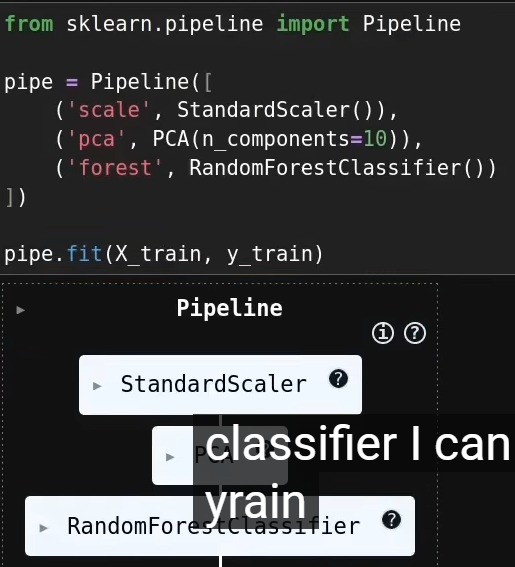

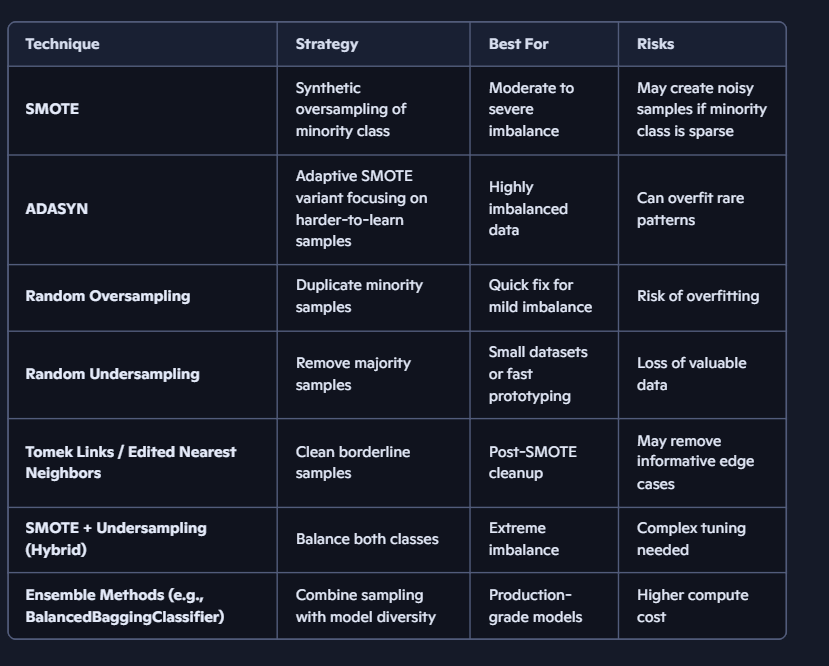

Types of Classificaiton